In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
# ---

# `cosine_scheduler` 수식 검증 실험

목표 수식:

$$
v_t =
\begin{cases}
\dfrac{t}{T_w}\, v_{\text{base}} & t < T_w \quad \text{(linear warmup)} \\[10pt]
v_{\text{final}} + \dfrac{1}{2}\big(v_{\text{base}} - v_{\text{final}}\big)
\left(1 + \cos\dfrac{\pi (t - T_w)}{T - T_w}\right) & t \ge T_w
\end{cases}
$$

- $T = $ `epochs * niter_per_ep` (전체 iteration 수)
- $T_w = $ `warmup_epochs * niter_per_ep`

이 노트북은 (1) 위 식을 numpy로 직접 구현해 실제 `utils.cosine_scheduler`와 일치함을 보이고,
(2) 경계값·길이·도함수를 수치로 확인하고, (3) DINO 실제 4종 스케줄을 그린다.

In [2]:
# 필요 패키지: numpy, plotly (>=6), kaleido  (matplotlib / torch 불필요)
import os
import sys

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sys.path.insert(0, "/home/sungwoo/projects/swcho/dino")
from utils import cosine_scheduler  # noqa: E402  (실제 DINO 구현)


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
print("numpy", np.__version__, "| 저장 위치:", HERE)

numpy 1.26.4 | 저장 위치: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/96998f37-0ba8-4661-b789-5c97a4b17440


## 1. 수식을 그대로 numpy로 옮겨 쓴 버전

코사인 구간의 각도 사상 $\theta(t) = \pi\dfrac{t - T_w}{T - T_w}$ 를 만들 때,
실제 DINO 구현은 분모로 **남은 iteration 개수** `len(iters)` $= T - T_w$ 를 쓴다
(즉 마지막 원소의 각도는 $\pi\frac{N-1}{N}$ 로 $\pi$ 에 살짝 못 미친다).
warmup 구간은 `np.linspace(start, base, T_w)` 로 양 끝을 포함해 균등 분할한다.

In [3]:
def my_cosine_scheduler(base_value, final_value, epochs, niter_per_ep,
                        warmup_epochs=0, start_warmup_value=0):
    """수식을 직접 옮긴 구현 (DINO utils.cosine_scheduler 와 동일해야 한다)."""
    T = epochs * niter_per_ep          # 전체 iteration
    Tw = warmup_epochs * niter_per_ep  # warmup iteration

    # (1) warmup: 원점(또는 start_warmup_value)을 지나는 1차함수
    if warmup_epochs > 0:
        warm = np.linspace(start_warmup_value, base_value, Tw)
    else:
        warm = np.array([])

    # (2) cosine: theta 를 [0, pi] 로 사상 -> (1+cos)/2 로 [1,0] 비율 -> 두 값 사이 내분
    n = T - Tw
    t_rel = np.arange(n)                       # t - Tw
    theta = np.pi * t_rel / n                  # [0, pi)
    ratio = 0.5 * (1.0 + np.cos(theta))        # 1 -> 0 으로 단조 감소
    cos_part = final_value + ratio * (base_value - final_value)

    return np.concatenate((warm, cos_part))


# 실제 DINO 호출 인자 3종으로 비교
CASES = [
    ("lr      ", dict(base_value=0.0005 * (64 * 8) / 256., final_value=1e-6,
                      epochs=100, niter_per_ep=1251, warmup_epochs=10)),
    ("wd      ", dict(base_value=0.04, final_value=0.4,
                      epochs=100, niter_per_ep=1251)),
    ("momentum", dict(base_value=0.996, final_value=1.0,
                      epochs=100, niter_per_ep=1251)),
    ("warmup≠0", dict(base_value=1.0, final_value=0.1, epochs=7, niter_per_ep=13,
                      warmup_epochs=2, start_warmup_value=0.3)),
]
for name, kw in CASES:
    mine, ref = my_cosine_scheduler(**kw), cosine_scheduler(**kw)
    print(f"{name}  allclose={np.allclose(mine, ref)}  "
          f"max|diff|={np.abs(mine - ref).max():.3e}  len={len(ref)}")

lr        allclose=True  max|diff|=0.000e+00  len=125100
wd        allclose=True  max|diff|=0.000e+00  len=125100
momentum  allclose=True  max|diff|=0.000e+00  len=125100
warmup≠0  allclose=True  max|diff|=0.000e+00  len=91


## 2. 배열 길이는 항상 `epochs * niter_per_ep`

`cosine_scheduler` 마지막 줄이 `assert len(schedule) == epochs * niter_per_ep` 다.
스케줄은 학습 **전에** 통째로 만들어지고 루프에서는 `schedule[it]` 로 조회만 하므로,
스케줄러에 상태가 없어 resume 이 자동으로 정확하다.

In [4]:
for name, kw in CASES:
    s = cosine_scheduler(**kw)
    T = kw["epochs"] * kw["niter_per_ep"]
    assert len(s) == T, (name, len(s), T)
    print(f"{name}  len={len(s)} == epochs*niter = {kw['epochs']}*{kw['niter_per_ep']} = {T}  OK")

lr        len=125100 == epochs*niter = 100*1251 = 125100  OK
wd        len=125100 == epochs*niter = 100*1251 = 125100  OK
momentum  len=125100 == epochs*niter = 100*1251 = 125100  OK
warmup≠0  len=91 == epochs*niter = 7*13 = 91  OK


## 3. 경계값 확인

- $t = 0$: warmup 시작 → `start_warmup_value` (기본 0)
- $t = T_w - 1$: warmup 마지막 원소 → $v_{\text{base}}$ (linspace 가 양 끝 포함)
- $t = T_w$: 코사인 구간 첫 원소 → $\cos 0 = 1$ 이므로 다시 $v_{\text{base}}$ (**값이 두 번 나온다**)
- $t = T-1$: 마지막 원소 → 각도가 $\pi\frac{N-1}{N}$ 이라 $v_{\text{final}}$ 에 *살짝* 못 미친다

In [5]:
EPOCHS, NITER = 100, 1251
WARM_EP = 10
Tw = WARM_EP * NITER
lr_base = 0.0005 * (64 * 8) / 256.
lr = cosine_scheduler(lr_base, 1e-6, EPOCHS, NITER, warmup_epochs=WARM_EP)

print(f"v_base      = {lr_base:.6e},  v_final = {1e-6:.6e},  T = {len(lr)}, Tw = {Tw}")
print(f"lr[0]       = {lr[0]:.6e}   (warmup 시작, start_warmup_value=0)")
print(f"lr[Tw-1]    = {lr[Tw-1]:.6e}   (warmup 마지막 == v_base)")
print(f"lr[Tw]      = {lr[Tw]:.6e}   (cosine 첫 원소 == v_base, cos0=1)")
print(f"argmax      = {lr.argmax()}  (Tw-1={Tw-1} 또는 Tw={Tw} 부근)")
print(f"lr[-1]      = {lr[-1]:.6e}   (v_final 에 살짝 못 미침)")
print(f"마지막-v_final 상대오차 = {(lr[-1] - 1e-6) / lr_base:.3e}  (v_base 대비)")

v_base      = 1.000000e-03,  v_final = 1.000000e-06,  T = 125100, Tw = 12510
lr[0]       = 0.000000e+00   (warmup 시작, start_warmup_value=0)
lr[Tw-1]    = 1.000000e-03   (warmup 마지막 == v_base)
lr[Tw]      = 1.000000e-03   (cosine 첫 원소 == v_base, cos0=1)
argmax      = 12509  (Tw-1=12509 또는 Tw=12510 부근)
lr[-1]      = 1.000000e-06   (v_final 에 살짝 못 미침)
마지막-v_final 상대오차 = 1.944e-10  (v_base 대비)


### 중간점은 정확히 두 값의 산술평균

$t = \dfrac{T_w + T}{2}$ 에서 $\cos\dfrac{\pi}{2} = 0$ 이므로
$v = v_{\text{final}} + \frac12 (v_{\text{base}} - v_{\text{final}}) = \dfrac{v_{\text{base}} + v_{\text{final}}}{2}$.

In [6]:
mid = Tw + (len(lr) - Tw) // 2
print(f"lr[mid]            = {lr[mid]:.9e}")
print(f"(v_base+v_final)/2 = {(lr_base + 1e-6) / 2:.9e}")
print("일치? ", np.isclose(lr[mid], (lr_base + 1e-6) / 2, rtol=1e-4))

lr[mid]            = 5.005000000e-04
(v_base+v_final)/2 = 5.005000000e-04
일치?  True


## 4. 왜 코사인인가 — 양 끝에서 도함수가 0

$$
\frac{dv}{dt} = -\frac{\pi\,(v_{\text{base}} - v_{\text{final}})}{2\,(T-T_w)}
\sin\frac{\pi(t-T_w)}{T-T_w}
$$

$\sin 0 = \sin\pi = 0$ 이므로 코사인 구간의 **시작과 끝에서 기울기가 0**(부드러운 착지),
중간 $\sin = 1$ 지점에서 가장 빠르게 변한다.
최대 변화율은 평균 변화율의 $\pi/2 \approx 1.571$ 배여야 한다.

In [7]:
cos_part = lr[Tw:]                       # 코사인 구간만
g = np.gradient(cos_part)                # 수치 미분 (iteration 당 변화량)
N = len(cos_part)
avg_rate = (lr_base - 1e-6) / N          # 평균 변화율(절댓값)

print(f"코사인 구간 길이 N = {N}")
print(f"시작 기울기 g[0]        = {g[0]:+.4e}   (0 에 가까움)")
print(f"끝   기울기 g[-1]       = {g[-1]:+.4e}   (0 에 가까움)")
print(f"중간 기울기 g[N//2]     = {g[N//2]:+.4e}   (가장 가파름)")
print(f"|g| 최대 위치           = {np.abs(g).argmax()} / {N}  (중앙 {N//2} 부근)")
print(f"|g|max / 평균변화율     = {np.abs(g).max()/avg_rate:.4f}   (이론값 pi/2 = {np.pi/2:.4f})")
print(f"|g[0]|,|g[-1]| / |g|max = {abs(g[0])/np.abs(g).max():.2e}, {abs(g[-1])/np.abs(g).max():.2e}")

코사인 구간 길이 N = 112590
시작 기울기 g[0]        = -1.9445e-13   (0 에 가까움)
끝   기울기 g[-1]       = -5.8335e-13   (0 에 가까움)
중간 기울기 g[N//2]     = -1.3938e-08   (가장 가파름)
|g| 최대 위치           = 56295 / 112590  (중앙 56295 부근)
|g|max / 평균변화율     = 1.5708   (이론값 pi/2 = 1.5708)
|g[0]|,|g[-1]| / |g|max = 1.40e-05, 4.19e-05


## 5. 부호가 뒤집히면? — 증가 스케줄도 같은 식 하나로

wd 는 $v_{\text{base}} = 0.04 < v_{\text{final}} = 0.4$ 라 $v_{\text{base}}-v_{\text{final}} < 0$.
곡선이 상하 반전될 뿐 경계값 성질은 그대로다.

In [8]:
for label, vb, vf in [("lr      ", lr_base, 1e-6), ("wd      ", 0.04, 0.4), ("momentum", 0.996, 1.0)]:
    s = cosine_scheduler(vb, vf, EPOCHS, NITER)   # warmup 없이
    print(f"{label} v_base-v_final = {vb - vf:+.6f}  |  s[0]={s[0]:.6f} (=v_base) "
          f"s[-1]={s[-1]:.6f} (≈v_final)  방향={'감소' if vb > vf else '증가'}")

lr       v_base-v_final = +0.000999  |  s[0]=0.001000 (=v_base) s[-1]=0.000001 (≈v_final)  방향=감소
wd       v_base-v_final = -0.360000  |  s[0]=0.040000 (=v_base) s[-1]=0.400000 (≈v_final)  방향=증가
momentum v_base-v_final = -0.004000  |  s[0]=0.996000 (=v_base) s[-1]=1.000000 (≈v_final)  방향=증가


## 6. 함정: `warmup_epochs > epochs` 면 assert 에서 죽는다

`iters = np.arange(epochs*niter_per_ep - warmup_iters)` 가 음수 길이가 되어 빈 배열이 되고,
전체 길이가 $T$ 에 못 미쳐 마지막 `assert` 가 실패한다.
짧게 스모크 테스트할 땐 `--warmup_epochs 0` 을 반드시 준다.

In [9]:
try:
    cosine_scheduler(0.0005, 1e-6, epochs=2, niter_per_ep=10, warmup_epochs=10)  # 기본 warmup 10 > epochs 2
    print("예외 없음 (?)")
except AssertionError as e:
    print(f"AssertionError 발생! repr={e!r}")
    print("  이유: warmup_iters=100 > epochs*niter=20 -> np.arange(-80)=빈 배열")
    print(f"  실제 만들어진 길이 = {len(np.linspace(0, 0.0005, 100)) + len(np.arange(20 - 100))}, 기대 = 20")
except ZeroDivisionError as e:
    print(f"ZeroDivisionError: {e}")

# warmup_epochs=0 이면 정상
ok = cosine_scheduler(0.0005, 1e-6, epochs=2, niter_per_ep=10, warmup_epochs=0)
print(f"warmup_epochs=0 -> len={len(ok)}, {ok[0]:.2e} → {ok[-1]:.2e}  OK")

AssertionError 발생! repr=AssertionError()
  이유: warmup_iters=100 > epochs*niter=20 -> np.arange(-80)=빈 배열
  실제 만들어진 길이 = 100, 기대 = 20
warmup_epochs=0 -> len=20, 5.00e-04 → 4.07e-06  OK


## 7. DINO 실제 4종 스케줄 시각화

| 스케줄 | $v_{\text{base}} \to v_{\text{final}}$ | warmup | 방향 |
|---|---|---|---|
| learning rate | $0.001 \to 10^{-6}$ (0 부터 warmup) | 10 epoch | 감소 |
| weight decay | $0.04 \to 0.4$ | 없음 | 증가 |
| teacher momentum | $0.996 \to 1.0$ | 없음 | 증가 |
| teacher temp | $0.04 \to 0.07$ | — | linear 30 epoch 후 상수 |

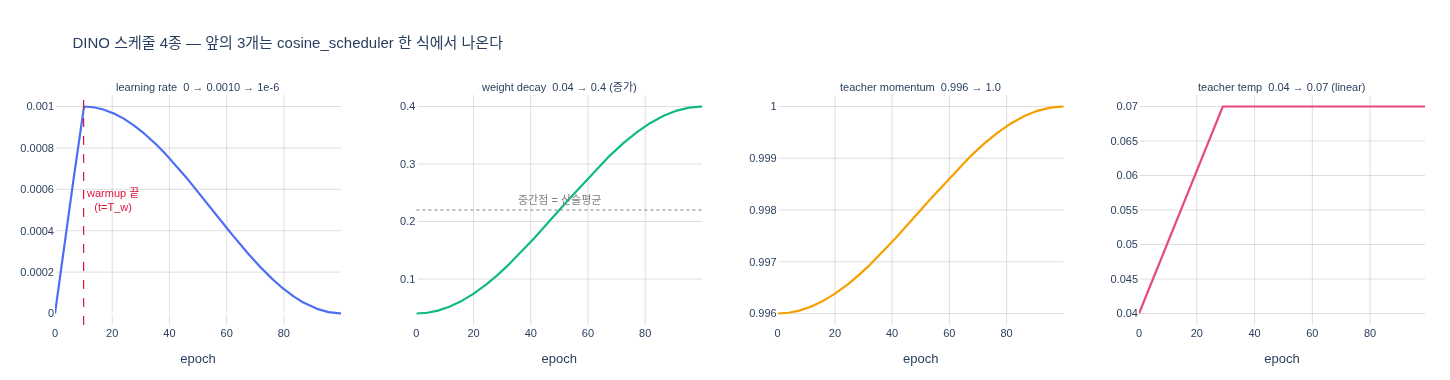

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/96998f37-0ba8-4661-b789-5c97a4b17440/expy.png True


In [10]:
lr_s = cosine_scheduler(lr_base, 1e-6, EPOCHS, NITER, warmup_epochs=10)
wd_s = cosine_scheduler(0.04, 0.4, EPOCHS, NITER)
mo_s = cosine_scheduler(0.996, 1.0, EPOCHS, NITER)
tt_s = np.concatenate([np.linspace(0.04, 0.07, 30), np.full(EPOCHS - 30, 0.07)])  # epoch 단위

ep = np.arange(EPOCHS * NITER) / NITER            # x축을 epoch 으로
ds = 50                                           # 그림용 다운샘플

panels = [
    (ep[::ds], lr_s[::ds], f"learning rate  0 → {lr_base:.4f} → 1e-6", "#4C6EF5"),
    (ep[::ds], wd_s[::ds], "weight decay  0.04 → 0.4 (증가)", "#12B886"),
    (ep[::ds], mo_s[::ds], "teacher momentum  0.996 → 1.0", "#F59F00"),
    (np.arange(EPOCHS), tt_s, "teacher temp  0.04 → 0.07 (linear)", "#E64980"),
]
fig = make_subplots(rows=1, cols=4, subplot_titles=[p[2] for p in panels],
                    horizontal_spacing=0.055)
for i, (x, y, title, c) in enumerate(panels, start=1):
    fig.add_trace(go.Scatter(x=x, y=y, mode="lines", line=dict(color=c, width=2.2),
                             name=title, showlegend=False), row=1, col=i)
    fig.update_xaxes(title_text="epoch", row=1, col=i, gridcolor="rgba(128,128,128,.25)")
    fig.update_yaxes(row=1, col=i, gridcolor="rgba(128,128,128,.25)")

# lr 패널에 warmup 경계 표시
fig.add_vline(x=10, line=dict(color="crimson", dash="dash", width=1.2), row=1, col=1)
fig.add_annotation(x=10, y=lr_base * 0.55, text="warmup 끝<br>(t=T_w)", showarrow=False,
                   xanchor="left", font=dict(color="crimson", size=10), row=1, col=1)
# 중간점 = 산술평균 표시 (wd 패널)
fig.add_hline(y=(0.04 + 0.4) / 2, line=dict(color="gray", dash="dot", width=1), row=1, col=2)
fig.add_annotation(x=50, y=(0.04 + 0.4) / 2, text="중간점 = 산술평균", showarrow=False,
                   yshift=10, font=dict(color="gray", size=9), row=1, col=2)

fig.update_layout(
    title="DINO 스케줄 4종 — 앞의 3개는 cosine_scheduler 한 식에서 나온다",
    height=380, width=1450, margin=dict(l=55, r=25, t=95, b=55),
    font=dict(size=11), plot_bgcolor="rgba(0,0,0,0)",
)
fig.update_annotations(font_size=11)
_show(fig)

png_path = os.path.join(HERE, "expy.png")
fig.write_image(png_path, scale=2)
print("saved:", png_path, os.path.exists(png_path))

## 8. 정리

1. $\frac{1+\cos\theta}{2}$ 로 $[0,1]$ 비율을 만들고, $v_{\text{final}} + (\cdot)(v_{\text{base}}-v_{\text{final}})$
   로 두 값 사이를 내분하고, $\theta = \pi\frac{t-T_w}{T-T_w}$ 로 시간축을 각도로 사상한다.
2. 경계: $t=T_w \Rightarrow v_{\text{base}}$, $t=T \Rightarrow v_{\text{final}}$, 중간 $\Rightarrow$ 산술평균.
3. 양 끝에서 $\frac{dv}{dt}=0$ (수치 확인: 최대 기울기의 $10^{-5}$ 배 수준), 최대 변화율은 평균의 $\pi/2$ 배.
4. $v_{\text{base}} < v_{\text{final}}$ 이면 그대로 증가 스케줄 — wd/momentum 이 같은 함수를 쓴다.
5. `warmup_epochs > epochs` 면 assert 실패.